In [1]:
from pathlib import Path
import numpy as np
import mne
import json
import os
from glob import glob
import re
from collections import defaultdict
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Define subjects 
#migraine group
group_a_subjects = [
    'sub-001', 'sub-006', 'sub-010', 'sub-011', 'sub-017', 'sub-018', 'sub-022', 'sub-023', 'sub-025', 'sub-027', 'sub-028',
    'sub-033', 'sub-034', 'sub-039', 'sub-042', 'sub-047', 'sub-048', 'sub-053', 'sub-054', 'sub-055', 'sub-059', 'sub-062', 'sub-063', 'sub-074',
    'sub-077', 'sub-084', 'sub-088', 'sub-090', 'sub-091'
]
#control group
group_b_subjects = [
    'sub-002', 'sub-003', 'sub-004', 'sub-007', 'sub-008', 'sub-009', 'sub-012', 'sub-013', 'sub-014', 'sub-015', 'sub-016', 'sub-019', 'sub-021',
    'sub-024', 'sub-026', 'sub-029', 'sub-031', 'sub-035', 'sub-036', 'sub-037', 'sub-040', 'sub-041', 'sub-043', 'sub-045', 'sub-046', 
    'sub-050', 'sub-056', 'sub-057', 'sub-058', 'sub-060', 'sub-061', 'sub-064', 'sub-069', 'sub-071',
    'sub-072', 'sub-073', 'sub-075', 'sub-076', 'sub-078', 'sub-081', 'sub-082', 'sub-083', 'sub-085', 'sub-086', 'sub-087' 
]

In [3]:
#ROIs

FRONTOCENTRAL_CHS = [
    'E13', 'E112', 'E29', 'E111', 'E28', 'E117', 'E6',
]
               
LEFT_TEMPORAL_CHS = [
    'E45', 'E44',
]

RIGHT_TEMPORAL_CHS = [
    'E114', 'E108',
]

RIGHT_PARIETAL_CHS = [ 
    'E92', 'E95', 'E85', 'E97',
]

LEFT_PARIETAL_CHS = [
    'E52', 'E60', 'E64',  'E51',
]

OCCIPITAL_CHS = [
    'E70', 'E83', 'E75', 'E67', 'E77', 'E65', 'E90', 'E72'
]

ROI_CHS = {
    "frontocentral": FRONTOCENTRAL_CHS,
    "leftparietal": LEFT_PARIETAL_CHS,
    "rightparietal": RIGHT_PARIETAL_CHS,
    "lefttemporal": LEFT_TEMPORAL_CHS,
    "righttemporal": RIGHT_TEMPORAL_CHS,
    "occipital": OCCIPITAL_CHS
}

In [6]:
#Negative film- full power spectrum, average of all electrodes
#Settings

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Negative film
TASK_CORE = "task-negativewicken_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100

NOTCH_LOW = 59
NOTCH_HIGH = 61

# Load negative film files

def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback

    return None


raw_dict = {}

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw_dict[sub] = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

print(f"Loaded {len(raw_dict)} subjects.")

#Calculate 0.1-100Hz PSD for each subject

subject_psds = {}
freqs = None

for sub, raw in raw_dict.items():

    sfreq = raw.info["sfreq"]

    # Same Welch parameters as power analysis:
    # 4-second windows, 50% overlap
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    eeg_picks = mne.pick_types(
        raw.info,
        eeg=True,
        exclude="bads"
    )

    spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=eeg_picks,
        verbose=False
    )

    psd = spectrum.get_data()

    # Average across all EEG electrodes -> one spectrum per subject
    subject_psds[sub] = psd.mean(axis=0)

    if freqs is None:
        freqs = spectrum.freqs

print(f"PSD calculated for {len(subject_psds)} subjects.")

#Interpolate 59-61Hz notch for visualization only

notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask


def interpolate_notch(y):
    y_plot = y.copy()

    y_plot[notch_mask] = np.interp(
        freqs[notch_mask],
        freqs[good_mask],
        y[good_mask]
    )

    return y_plot

#Plot 1: all subjects

all_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects + group_b_subjects
    if sub in subject_psds
])

#Average in linear PSD units first
mean_all = all_psds.mean(axis=0)

#Convert the resulting mean spectrum to dB
mean_all_db = 10 * np.log10(mean_all)

#Fill the notch only for plotting
mean_all_db_plot = interpolate_notch(mean_all_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_all_db_plot,
    linewidth=2
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    f"Negative Film — Full Power Spectrum — "
    f"All Subjects (n={len(all_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    DESKTOP / "Negative_FullPowerSpectrum_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Plot 2: migraine vs control

migraine_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects
    if sub in subject_psds
])

control_psds = np.array([
    subject_psds[sub]
    for sub in group_b_subjects
    if sub in subject_psds
])


#Average each group in linear PSD units
mean_migraine = migraine_psds.mean(axis=0)
mean_control = control_psds.mean(axis=0)

#Convert group means to dB
mean_migraine_db = 10 * np.log10(mean_migraine)
mean_control_db = 10 * np.log10(mean_control)

#Fill notch only for visualization
mean_migraine_db_plot = interpolate_notch(mean_migraine_db)
mean_control_db_plot = interpolate_notch(mean_control_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_migraine_db_plot,
    linewidth=2,
    label=f"Migraine (n={len(migraine_psds)})"
)

plt.plot(
    freqs,
    mean_control_db_plot,
    linewidth=2,
    label=f"Control (n={len(control_psds)})"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Negative Film — Full Power Spectrum\n"
    "Migraine vs Control"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    DESKTOP / "Negative_FullPowerSpectrum_Migraine_vs_Control.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/2547962407.py:44: RuntimeWarning

KeyboardInterrupt: 

/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3300090448.py:42: RuntimeWarning: The data contains 'boundary' events, indicating 

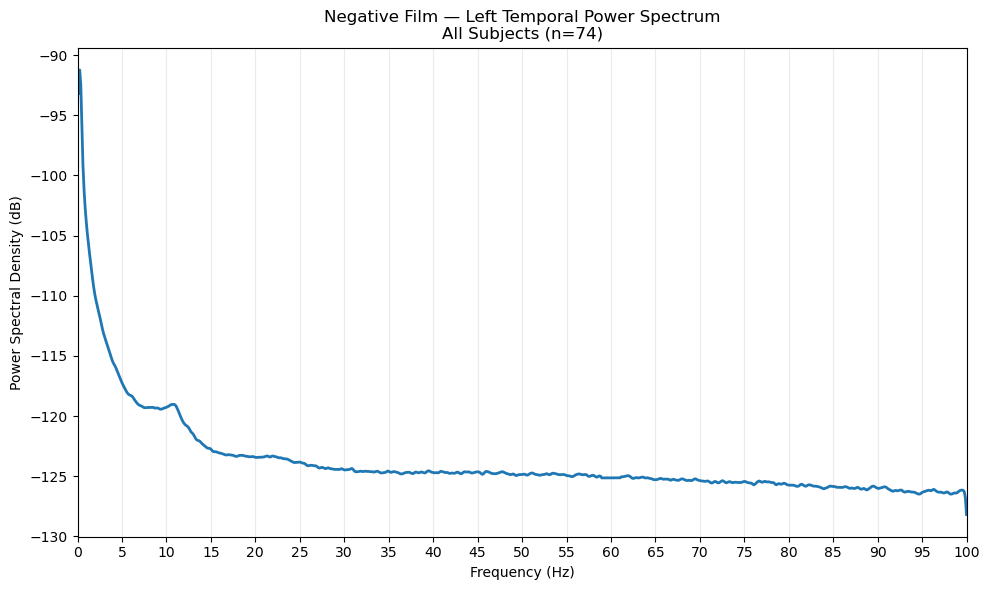

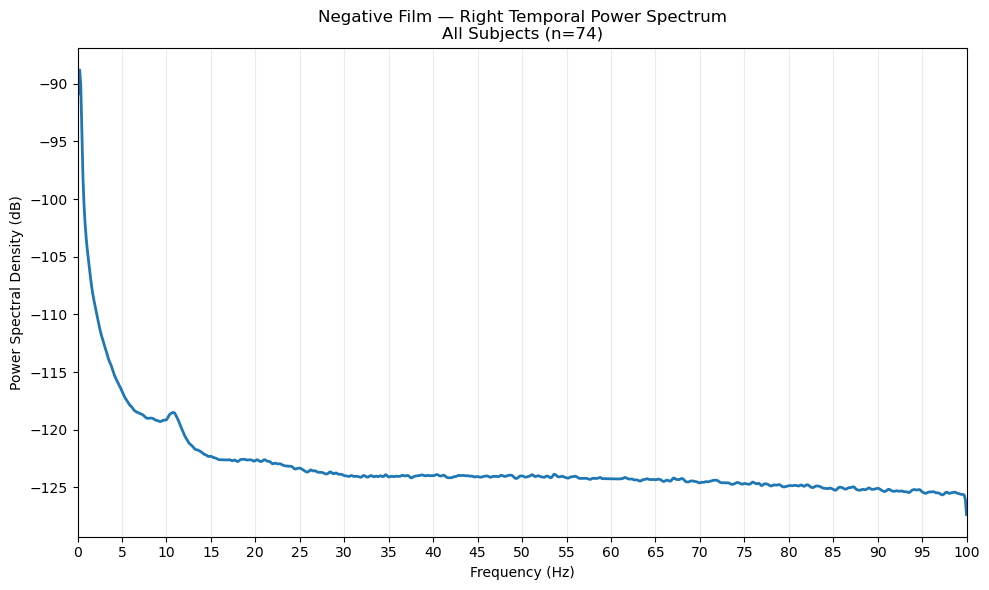

In [12]:
#Negative film: full power spectrum in left and right temporal ROIs

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Negative film
TASK_CORE = "task-negativewicken_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100
NOTCH_LOW = 59
NOTCH_HIGH = 61


def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return None


left_psds = []
right_psds = []
freqs = None

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

    sfreq = raw.info["sfreq"]
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    left_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=LEFT_TEMPORAL_CHS,
        verbose=False
    )

    right_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=RIGHT_TEMPORAL_CHS,
        verbose=False
    )

    left_psds.append(left_spectrum.get_data().mean(axis=0))
    right_psds.append(right_spectrum.get_data().mean(axis=0))

    if freqs is None:
        freqs = left_spectrum.freqs


#Average subjects in linear PSD units, then convert to dB
left_mean_db = 10 * np.log10(np.array(left_psds).mean(axis=0))
right_mean_db = 10 * np.log10(np.array(right_psds).mean(axis=0))


#Interpolate 59–61 Hz notch for visualization only
notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask

left_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    left_mean_db[good_mask]
)

right_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    right_mean_db[good_mask]
)


#Left temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, left_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Negative Film — Left Temporal Power Spectrum\n"
    f"All Subjects (n={len(left_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Negative_FullPowerSpectrum_LeftTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Right temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, right_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Negative Film — Right Temporal Power Spectrum\n"
    f"All Subjects (n={len(right_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Negative_FullPowerSpectrum_RightTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


/tmp/ipykernel_973436/1536073971.py:43: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/1536073971.py:43: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/1536073971.py:43: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/1536073971.py:43: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/1536073971.py:43: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/1536073971.py:43: RuntimeW

Loaded 74 subjects.
PSD calculated for 74 subjects.


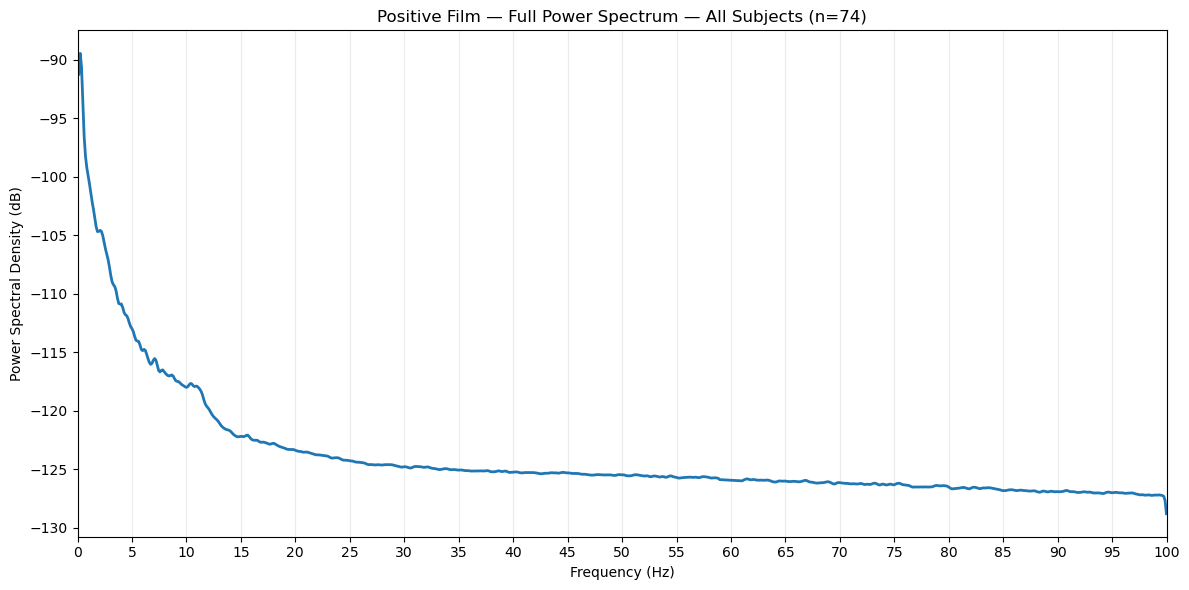

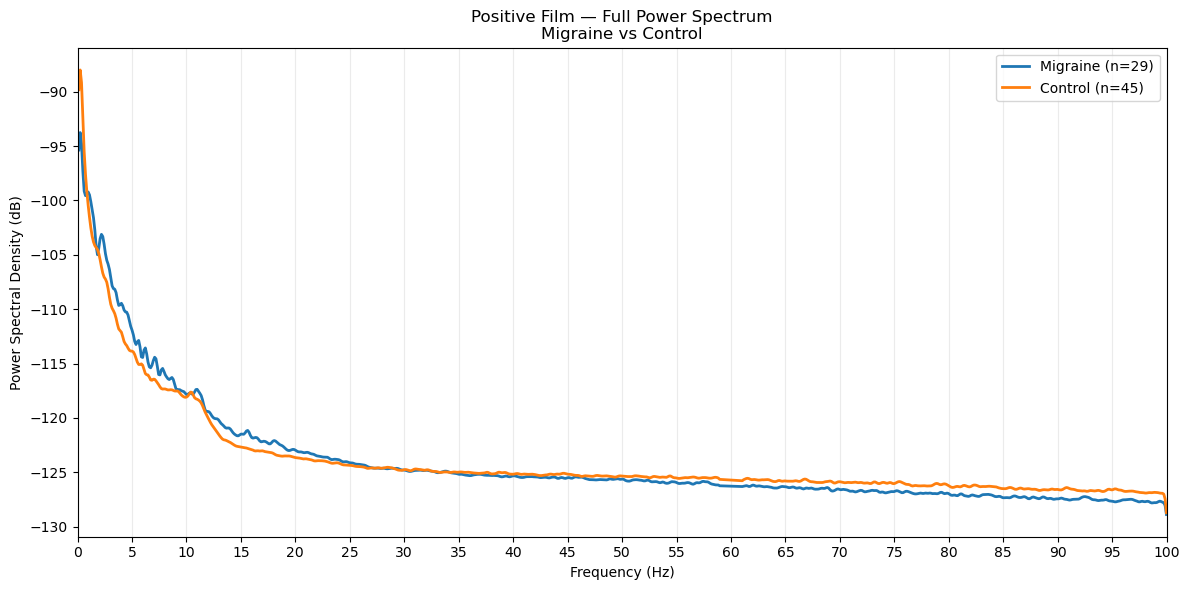

In [6]:
#Positive film- full power spectrum, average of all electrodes
#Settings

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Positive film
TASK_CORE = "task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100

NOTCH_LOW = 59
NOTCH_HIGH = 61

# Load positive film files

def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback

    return None


raw_dict = {}

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw_dict[sub] = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

print(f"Loaded {len(raw_dict)} subjects.")

#Calculate 0.1-100Hz PSD for each subject

subject_psds = {}
freqs = None

for sub, raw in raw_dict.items():

    sfreq = raw.info["sfreq"]

    # Same Welch parameters as power analysis:
    # 4-second windows, 50% overlap
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    eeg_picks = mne.pick_types(
        raw.info,
        eeg=True,
        exclude="bads"
    )

    spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=eeg_picks,
        verbose=False
    )

    psd = spectrum.get_data()

    # Average across all EEG electrodes -> one spectrum per subject
    subject_psds[sub] = psd.mean(axis=0)

    if freqs is None:
        freqs = spectrum.freqs

print(f"PSD calculated for {len(subject_psds)} subjects.")

#Interpolate 59-61Hz notch for visualization only

notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask


def interpolate_notch(y):
    y_plot = y.copy()

    y_plot[notch_mask] = np.interp(
        freqs[notch_mask],
        freqs[good_mask],
        y[good_mask]
    )

    return y_plot

#Plot 1: all subjects

all_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects + group_b_subjects
    if sub in subject_psds
])

#Average in linear PSD units first
mean_all = all_psds.mean(axis=0)

#Convert the resulting mean spectrum to dB
mean_all_db = 10 * np.log10(mean_all)

#Fill the notch only for plotting
mean_all_db_plot = interpolate_notch(mean_all_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_all_db_plot,
    linewidth=2
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    f"Positive Film — Full Power Spectrum — "
    f"All Subjects (n={len(all_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    DESKTOP / "Positive_FullPowerSpectrum_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Plot 2: migraine vs control

migraine_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects
    if sub in subject_psds
])

control_psds = np.array([
    subject_psds[sub]
    for sub in group_b_subjects
    if sub in subject_psds
])


#Average each group in linear PSD units
mean_migraine = migraine_psds.mean(axis=0)
mean_control = control_psds.mean(axis=0)

#Convert group means to dB
mean_migraine_db = 10 * np.log10(mean_migraine)
mean_control_db = 10 * np.log10(mean_control)

#Fill notch only for visualization
mean_migraine_db_plot = interpolate_notch(mean_migraine_db)
mean_control_db_plot = interpolate_notch(mean_control_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_migraine_db_plot,
    linewidth=2,
    label=f"Migraine (n={len(migraine_psds)})"
)

plt.plot(
    freqs,
    mean_control_db_plot,
    linewidth=2,
    label=f"Control (n={len(control_psds)})"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Positive Film — Full Power Spectrum\n"
    "Migraine vs Control"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    DESKTOP / "Positive_FullPowerSpectrum_Migraine_vs_Control.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3669946931.py:42: RuntimeWarning: The data contains 'boundary' events, indicating 

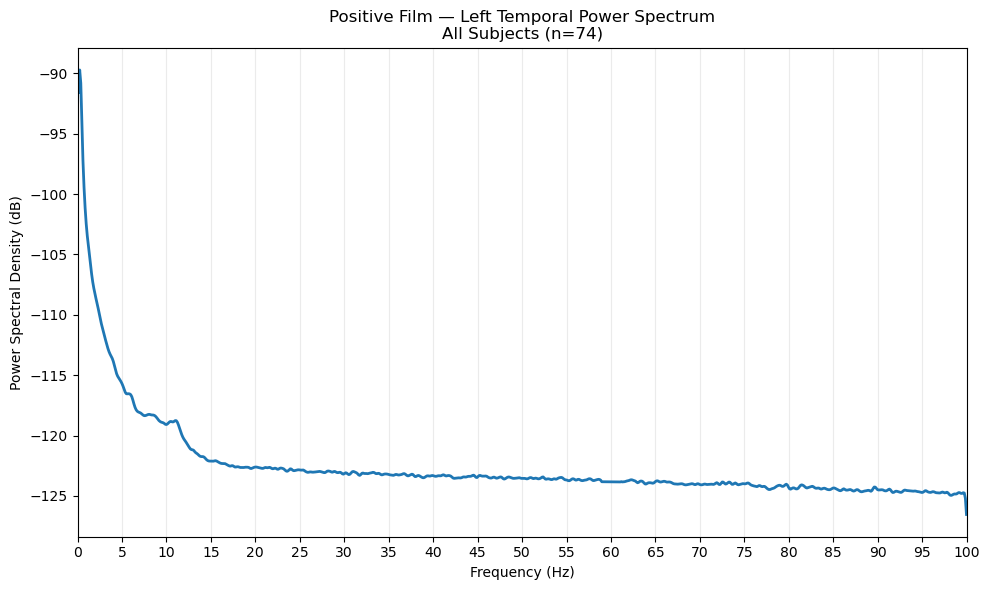

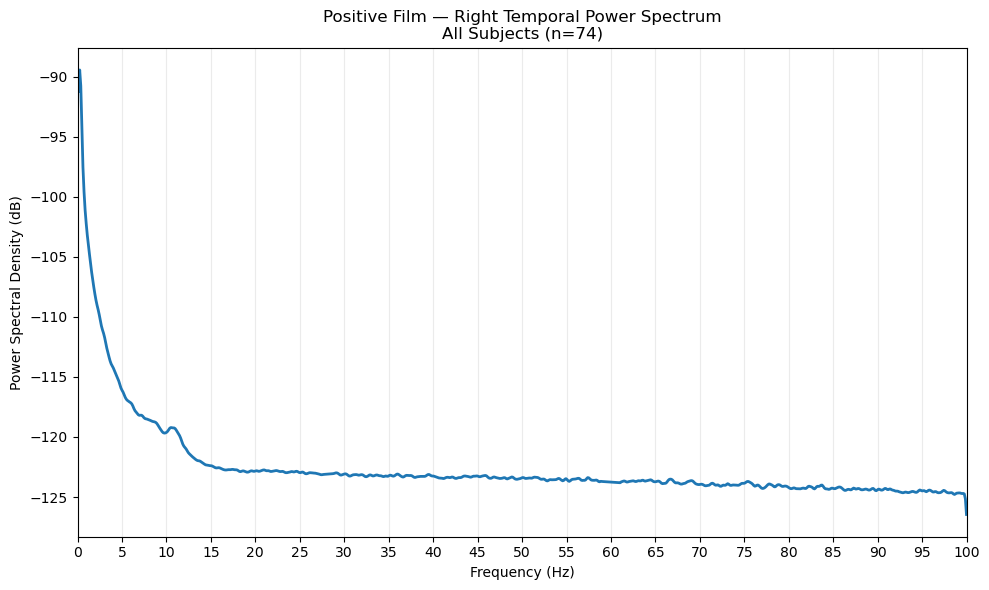

In [13]:
#Positive film: full power spectrum in left and right temporal ROIs

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Positive film
TASK_CORE = "task-positivetimemachine_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100
NOTCH_LOW = 59
NOTCH_HIGH = 61


def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return None


left_psds = []
right_psds = []
freqs = None

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

    sfreq = raw.info["sfreq"]
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    left_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=LEFT_TEMPORAL_CHS,
        verbose=False
    )

    right_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=RIGHT_TEMPORAL_CHS,
        verbose=False
    )

    left_psds.append(left_spectrum.get_data().mean(axis=0))
    right_psds.append(right_spectrum.get_data().mean(axis=0))

    if freqs is None:
        freqs = left_spectrum.freqs


#Average subjects in linear PSD units, then convert to dB
left_mean_db = 10 * np.log10(np.array(left_psds).mean(axis=0))
right_mean_db = 10 * np.log10(np.array(right_psds).mean(axis=0))


#Interpolate 59–61 Hz notch for visualization only
notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask

left_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    left_mean_db[good_mask]
)

right_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    right_mean_db[good_mask]
)


#Left temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, left_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Positive Film — Left Temporal Power Spectrum\n"
    f"All Subjects (n={len(left_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Positive_FullPowerSpectrum_LeftTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Right temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, right_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Positive Film — Right Temporal Power Spectrum\n"
    f"All Subjects (n={len(right_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Positive_FullPowerSpectrum_RightTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw_dict[sub] = mne.io.read_raw_eeglab(
/tmp/ipykernel_973436/213595519.py:43: RuntimeWarning

Loaded 74 subjects.
PSD calculated for 74 subjects.


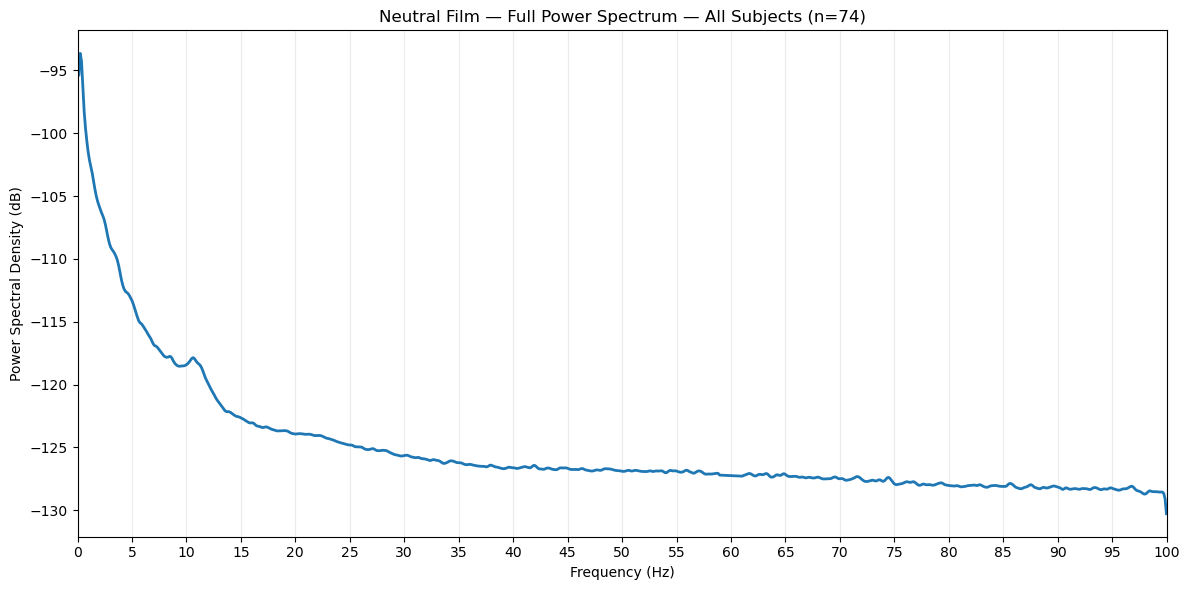

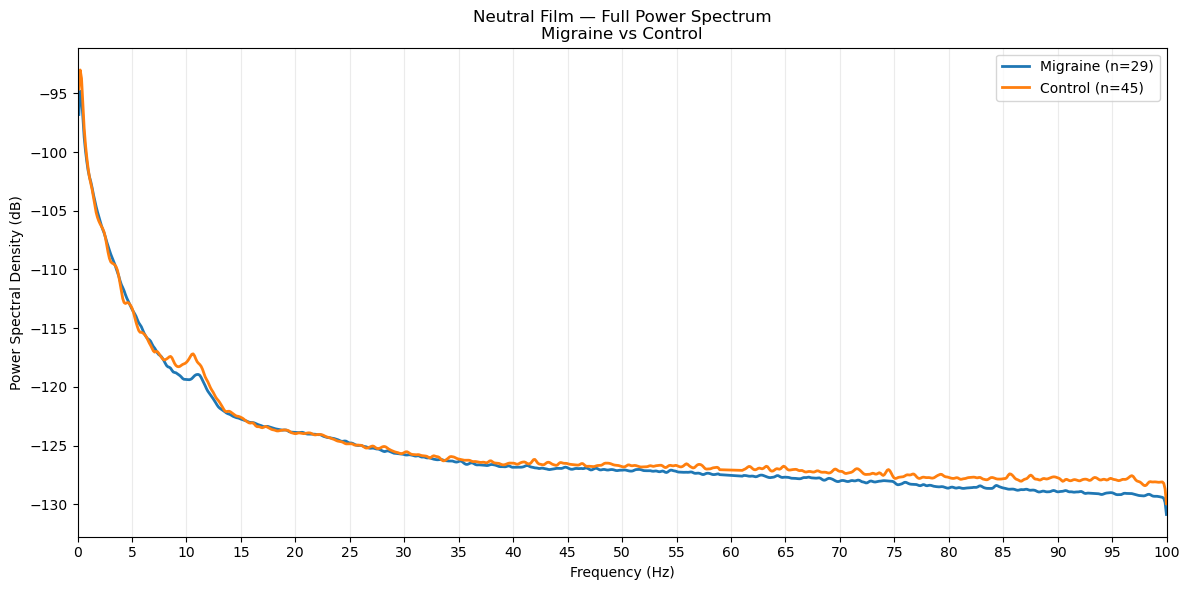

In [8]:
#Neutral film- full power spectrum, average of all electrodes
#Settings

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Neutral film
TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100

NOTCH_LOW = 59
NOTCH_HIGH = 61

# Load neutral film files

def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback

    return None


raw_dict = {}

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw_dict[sub] = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

print(f"Loaded {len(raw_dict)} subjects.")

#Calculate 0.1-100Hz PSD for each subject

subject_psds = {}
freqs = None

for sub, raw in raw_dict.items():

    sfreq = raw.info["sfreq"]

    # Same Welch parameters as power analysis:
    # 4-second windows, 50% overlap
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    eeg_picks = mne.pick_types(
        raw.info,
        eeg=True,
        exclude="bads"
    )

    spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=eeg_picks,
        verbose=False
    )

    psd = spectrum.get_data()

    # Average across all EEG electrodes -> one spectrum per subject
    subject_psds[sub] = psd.mean(axis=0)

    if freqs is None:
        freqs = spectrum.freqs

print(f"PSD calculated for {len(subject_psds)} subjects.")

#Interpolate 59-61Hz notch for visualization only

notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask


def interpolate_notch(y):
    y_plot = y.copy()

    y_plot[notch_mask] = np.interp(
        freqs[notch_mask],
        freqs[good_mask],
        y[good_mask]
    )

    return y_plot

#Plot 1: all subjects

all_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects + group_b_subjects
    if sub in subject_psds
])

#Average in linear PSD units first
mean_all = all_psds.mean(axis=0)

#Convert the resulting mean spectrum to dB
mean_all_db = 10 * np.log10(mean_all)

#Fill the notch only for plotting
mean_all_db_plot = interpolate_notch(mean_all_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_all_db_plot,
    linewidth=2
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    f"Neutral Film — Full Power Spectrum — "
    f"All Subjects (n={len(all_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_FullPowerSpectrum_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#Plot 2: migraine vs control

migraine_psds = np.array([
    subject_psds[sub]
    for sub in group_a_subjects
    if sub in subject_psds
])

control_psds = np.array([
    subject_psds[sub]
    for sub in group_b_subjects
    if sub in subject_psds
])


#Average each group in linear PSD units
mean_migraine = migraine_psds.mean(axis=0)
mean_control = control_psds.mean(axis=0)

#Convert group means to dB
mean_migraine_db = 10 * np.log10(mean_migraine)
mean_control_db = 10 * np.log10(mean_control)

#Fill notch only for visualization
mean_migraine_db_plot = interpolate_notch(mean_migraine_db)
mean_control_db_plot = interpolate_notch(mean_control_db)


plt.figure(figsize=(12, 6))

plt.plot(
    freqs,
    mean_migraine_db_plot,
    linewidth=2,
    label=f"Migraine (n={len(migraine_psds)})"
)

plt.plot(
    freqs,
    mean_control_db_plot,
    linewidth=2,
    label=f"Control (n={len(control_psds)})"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Neutral Film — Full Power Spectrum\n"
    "Migraine vs Control"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.legend()

plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_FullPowerSpectrum_Migraine_vs_Control.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: Limited 4 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: Limited 3 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab(
/tmp/ipykernel_90549/3836789544.py:42: RuntimeWarning: The data contains 'boundary' events, indicating 

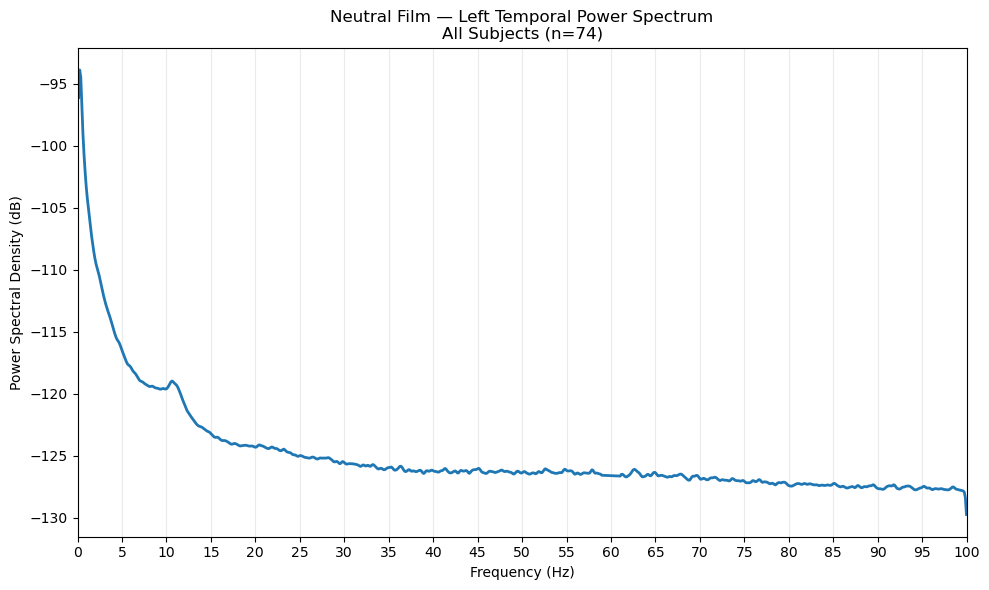

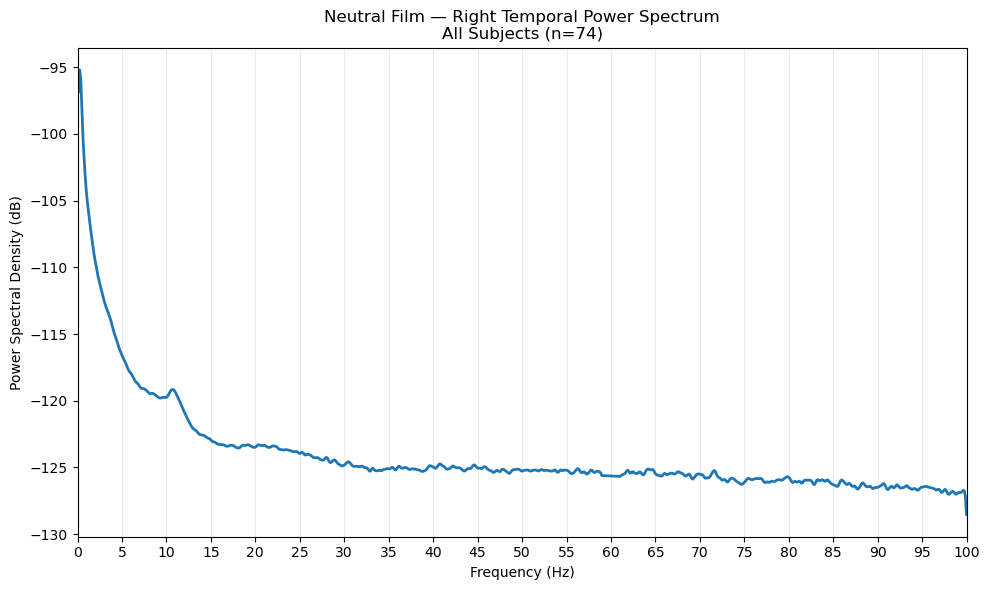

In [14]:
#Neutral film: full power spectrum in left and right temporal ROIs

BASE_DIR = Path("/media/ekstrandlab/eeg_backup/preprocessed/subjects")
DESKTOP = Path.home() / "Desktop"

#Neutral film
TASK_CORE = "task-neutraltrainingvideo_eeg_fil01to100_notch60_seg_bcd"

PREFERRED = f"_{TASK_CORE}_bcr_reref_ICA.set"
FALLBACK  = f"_{TASK_CORE}_reref_ICA.set"

FMIN = 0.1
FMAX = 100
NOTCH_LOW = 59
NOTCH_HIGH = 61


def pick_set(eeglab_dir, sub):
    preferred = eeglab_dir / f"{sub}{PREFERRED}"
    fallback = eeglab_dir / f"{sub}{FALLBACK}"

    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    return None


left_psds = []
right_psds = []
freqs = None

for sub in group_a_subjects + group_b_subjects:

    eeglab_dir = BASE_DIR / sub / "eeglab2"
    in_set = pick_set(eeglab_dir, sub)

    if in_set is None:
        print(f"{sub}: no matching .set file found")
        continue

    raw = mne.io.read_raw_eeglab(
        str(in_set),
        preload=True,
        verbose=False
    )

    sfreq = raw.info["sfreq"]
    n_per_seg = int(sfreq * 4)
    n_overlap = int(n_per_seg * 0.5)
    n_fft = 8192

    left_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=LEFT_TEMPORAL_CHS,
        verbose=False
    )

    right_spectrum = raw.compute_psd(
        method="welch",
        fmin=FMIN,
        fmax=FMAX,
        n_fft=n_fft,
        n_per_seg=n_per_seg,
        n_overlap=n_overlap,
        window="hann",
        picks=RIGHT_TEMPORAL_CHS,
        verbose=False
    )

    left_psds.append(left_spectrum.get_data().mean(axis=0))
    right_psds.append(right_spectrum.get_data().mean(axis=0))

    if freqs is None:
        freqs = left_spectrum.freqs


#Average subjects in linear PSD units, then convert to dB
left_mean_db = 10 * np.log10(np.array(left_psds).mean(axis=0))
right_mean_db = 10 * np.log10(np.array(right_psds).mean(axis=0))


#Interpolate 59–61 Hz notch for visualization only
notch_mask = (freqs >= NOTCH_LOW) & (freqs <= NOTCH_HIGH)
good_mask = ~notch_mask

left_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    left_mean_db[good_mask]
)

right_mean_db[notch_mask] = np.interp(
    freqs[notch_mask],
    freqs[good_mask],
    right_mean_db[good_mask]
)


#Left temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, left_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Neutral Film — Left Temporal Power Spectrum\n"
    f"All Subjects (n={len(left_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_FullPowerSpectrum_LeftTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


#Right temporal
plt.figure(figsize=(10, 6))
plt.plot(freqs, right_mean_db, linewidth=2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title(
    "Neutral Film — Right Temporal Power Spectrum\n"
    f"All Subjects (n={len(right_psds)})"
)

plt.xlim(0, 100)
plt.xticks(np.arange(0, 101, 5))
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

plt.savefig(
    DESKTOP / "Neutral_FullPowerSpectrum_RightTemporal_AllSubjects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()